# Homework 2 - MTH 602

William Girard

Due Date: September 30th, 2026

## Floating Point Numbers

### 1. (15 points) Consider an 𝑁-term Taylor series expansion of the exponential function

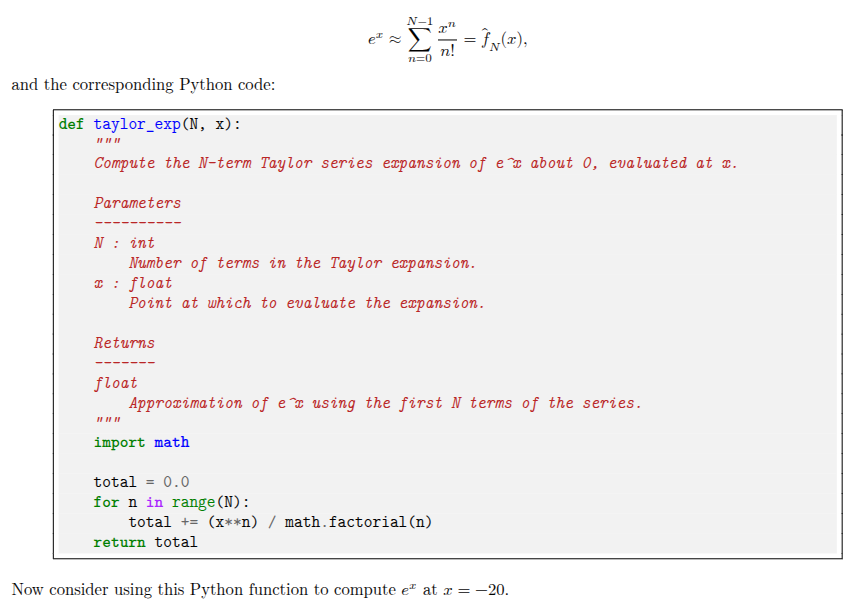

(a) (5 points) Plot the relative error 

\begin{align*}
  E_N = \frac{|\hat{f}_N(-20) - e^{-20}|}{|e^{-20}|}
\end{align*}

as a function of 𝑁 for 𝑁 = 1, 2, ....  What is the smallest relative error you can achieve?  Make the plot using a 
semilog-𝑦 scale.


In [3]:
import math

In [1]:
def taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)

    return total

In [4]:
# experiment with a few large values of N

print(taylor_exp(200, -20))
print(taylor_exp(500, -20))
print(taylor_exp(1000, -20))

5.47810291652921e-10
5.47810291652921e-10
5.47810291652921e-10


In [5]:
N = 200 # higher N values don't approximate better
error_list = []

for n in range(1, N+1):

    approx = taylor_exp(n, -20)
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

print(min(error_list))

0.5665545568629835


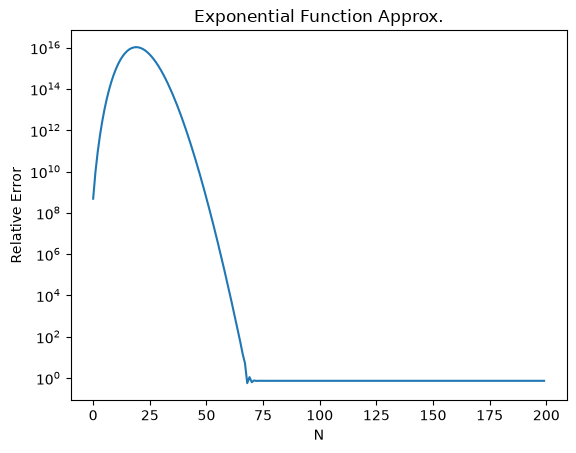


Minimum error obtained was: 0.5665545568629835


In [8]:
import matplotlib.pyplot as plt

plt.plot(list(range(N)), error_list)
plt.semilogy()
plt.title('Exponential Function Approx.')
plt.xlabel('N')
plt.ylabel('Relative Error')
plt.show()

print(f'\nMinimum error obtained was: {min(error_list)}')

The relative error starts off very high before dropping down and becoming constant. However, the minimum error of 0.5665545568629835 is much much larger than the expected error of $10^{-16}$ , so, clearly something is wrong.

(b) (5 points) You should find the relative error is much larger than the expected value of $\approx 10^{-16}$. Briefly explain the 
numerical reason for this behavior (hint: think about cancellation when 𝑥 is negative and large in magnitude).

In [41]:
# print each term in the taylor series
# will help me answer part B by investigating what the terms are actually evaluating to 

def mod_taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)
        print(f'Current term: {(x**n) / math.factorial(n)} - Running Total: {total}')

    return total

total = mod_taylor_exp(100, -20)
print(f'\nTotal: {total}')

Current term: 1.0 - Running Total: 1.0
Current term: -20.0 - Running Total: -19.0
Current term: 200.0 - Running Total: 181.0
Current term: -1333.3333333333333 - Running Total: -1152.3333333333333
Current term: 6666.666666666667 - Running Total: 5514.333333333334
Current term: -26666.666666666668 - Running Total: -21152.333333333336
Current term: 88888.88888888889 - Running Total: 67736.55555555556
Current term: -253968.25396825396 - Running Total: -186231.6984126984
Current term: 634920.6349206349 - Running Total: 448688.9365079365
Current term: -1410934.7442680777 - Running Total: -962245.8077601411
Current term: 2821869.4885361553 - Running Total: 1859623.6807760142
Current term: -5130671.797338464 - Running Total: -3271048.1165624503
Current term: 8551119.662230773 - Running Total: 5280071.545668323
Current term: -13155568.711124267 - Running Total: -7875497.165455945
Current term: 18793669.58732038 - Running Total: 10918172.421864435
Current term: -25058226.116427176 - Running Tota

The above printed lines reveal the reason why the actual error is so much higher than the expected error. The term is constantly being added to negative numbers. Therefore, two problems with computer arrithmatic are coming together to cause a huge problem: rounding errors and catastrophic cancellation.

1) Rounding errors are occuring due to the limited precision of computers. Decimal numbers may be unbound, but a computer can only store the integer result up to either 32 or 64 bits depending on your architecture. Normally, this isn't too much of a problem. But repeated subtraction of rounded numbers can result in catastrophic cancellation.
2) According to David Goldberg, "Catastrophic cancellation occurs when the operands are subject to rounding errors." When the cancellation occurs, many of the actually accurate bits/digits may disappear, leaving behind bits/digits contaiminated by rounding error. 

[David Goldberg's paper](https://docs.oracle.com/cd/E19957-01/806-3568/ncg_goldberg.html)

Therefore, the most obvious solution would be to avoid catastrophic cancellation, which means avoiding subtraction of rounded floating point numbers. 

To do this, I looked up expoential rules in hopes of finding an equivalent to the negative power. Thankfully, a negative exponent can be represented as:

$$
a^{-x} = \frac{1}{a^x}
$$

Therefore, all you need to do to avoid the catastrophic cancellation is to compute $x^{20}$ and then do 1 divided by $x^{20}$ to obtain $x^{-20}$

In [9]:
N = 200 # higher N values don't approximate better
error_list = []

for n in range(1, N+1):

    approx_pos = taylor_exp(n, 20) # compute regular e^20
    approx = 1/approx_pos # get e^-20 by doing 1/e^20
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

print(min(error_list))

2.0065962176423985e-16


As can be observed, the error is now $2 \times 10^{-16}$, which is a much closer expected error when compared to the original error of a very large 0.5